# mmraz-qwen3-32b-time-utility-probe-steering-plots

Small plotting notebook for the saved Qwen3-32B time-utility probe-steering runs.

It:
- finds the latest Qwen3-32B steered time-utility run by default,
- loads the saved summary/config artifacts,
- replots the `choose x = 100 now` heatmaps across steering conditions in the same style as the Qwen3 Vast baseline plotting notebook, and
- saves the combined replot under a `replots_from_notebook/` subdirectory inside the selected run folder.

In [1]:
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.rcParams['figure.dpi'] = 130

RUN_DIR_OVERRIDE = globals().get('RUN_DIR_OVERRIDE', None)
BASELINE_SUMMARY_OVERRIDE = globals().get('BASELINE_SUMMARY_OVERRIDE', None)


def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(8):
        if (p / 'pyproject.toml').exists() and (p / 'notebooks').exists():
            return p
        p = p.parent
    raise RuntimeError('Could not locate repo root from current working directory.')


def resolve_run_bundle(run_dir: Path):
    summary_candidates = sorted(run_dir.glob('mmraz_time_utility_qwen3_32b_probe_steered_summary_*.csv'))
    config_candidates = sorted(run_dir.glob('mmraz_time_utility_qwen3_32b_probe_steered_config_*.json'))
    plot_index_candidates = sorted(run_dir.glob('mmraz_time_utility_qwen3_32b_probe_steered_plots_*.csv'))
    artifact_index_candidates = sorted(run_dir.glob('mmraz_time_utility_qwen3_32b_probe_steered_artifacts_*.csv'))
    raw_candidates = sorted(run_dir.glob('mmraz_time_utility_qwen3_32b_probe_steered_raw_*.csv'))
    if not summary_candidates:
        raise FileNotFoundError(f'No steered summary CSV found under: {run_dir}')
    return {
        'summary_path': summary_candidates[-1],
        'config_path': config_candidates[-1] if config_candidates else None,
        'plot_index_path': plot_index_candidates[-1] if plot_index_candidates else None,
        'artifact_index_path': artifact_index_candidates[-1] if artifact_index_candidates else None,
        'raw_path': raw_candidates[-1] if raw_candidates else None,
        'partial_dir': run_dir / 'partial',
    }


ROOT = find_repo_root(Path.cwd())
RESULTS_ROOT = ROOT / 'results' / 'qwen3_32b' / 'time_utility_experiment_probe_steered'
DEFAULT_BASELINE_SUMMARY_PATH = (
    ROOT
    / 'results'
    / 'time_utility_experiment_qwen3_32b_vast_deterministic_without_thinking'
    / 'mmraz_time_utility_qwen3_32b_vast_without_thinking_summary.csv'
)
BASELINE_SUMMARY_PATH = (
    Path(BASELINE_SUMMARY_OVERRIDE).expanduser().resolve()
    if BASELINE_SUMMARY_OVERRIDE is not None
    else DEFAULT_BASELINE_SUMMARY_PATH.resolve()
)

RUN_AVAILABLE = False
RUN_DIR = None
bundle = None
config = {}

if RUN_DIR_OVERRIDE is not None:
    RUN_DIR = Path(RUN_DIR_OVERRIDE).expanduser().resolve()
    bundle = resolve_run_bundle(RUN_DIR)
    RUN_AVAILABLE = True
elif RESULTS_ROOT.exists():
    run_dirs = sorted([path for path in RESULTS_ROOT.iterdir() if path.is_dir()])
    if run_dirs:
        RUN_DIR = run_dirs[-1]
        bundle = resolve_run_bundle(RUN_DIR)
        RUN_AVAILABLE = True

if RUN_AVAILABLE:
    SUMMARY_PATH = bundle['summary_path']
    CONFIG_PATH = bundle['config_path']
    PLOT_INDEX_PATH = bundle['plot_index_path']
    ARTIFACT_INDEX_PATH = bundle['artifact_index_path']
    RAW_PATH = bundle['raw_path']
    PARTIAL_DIR = bundle['partial_dir']
    PLOT_ROOT = RUN_DIR / 'replots_from_notebook'
    PLOT_ROOT.mkdir(parents=True, exist_ok=True)
    if CONFIG_PATH is not None and CONFIG_PATH.exists():
        config = json.loads(CONFIG_PATH.read_text(encoding='utf-8'))

    run_id = str(config.get('run_id', RUN_DIR.name))
    print('Repo root       :', ROOT)
    print('Results root    :', RESULTS_ROOT)
    print('Selected run    :', RUN_DIR.name)
    print('Run ID          :', run_id)
    print('Steering layer  :', config.get('steering_layer'))
    print('Probe regime    :', config.get('probe_train_regime'))
    print('Probe feature   :', config.get('probe_feature_name'))
    print('Probe vector    :', config.get('probe_vector_key'))
    print('Summary path    :', SUMMARY_PATH)
    print('Config path     :', CONFIG_PATH)
    print('Raw path        :', RAW_PATH)
    print('Plot root       :', PLOT_ROOT)
    print('Baseline path   :', BASELINE_SUMMARY_PATH)
    display(pd.DataFrame([
        {'kind': 'steering_layer', 'path': str(config.get('steering_layer', ''))},
        {'kind': 'probe_train_regime', 'path': str(config.get('probe_train_regime', ''))},
        {'kind': 'probe_feature_name', 'path': str(config.get('probe_feature_name', ''))},
        {'kind': 'probe_vector_key', 'path': str(config.get('probe_vector_key', ''))},
        {'kind': 'summary_csv', 'path': str(SUMMARY_PATH)},
        {'kind': 'config_json', 'path': str(CONFIG_PATH) if CONFIG_PATH else ''},
        {'kind': 'raw_csv', 'path': str(RAW_PATH) if RAW_PATH else ''},
        {'kind': 'baseline_summary_csv', 'path': str(BASELINE_SUMMARY_PATH)},
        {'kind': 'plot_index_csv', 'path': str(PLOT_INDEX_PATH) if PLOT_INDEX_PATH else ''},
        {'kind': 'artifact_index_csv', 'path': str(ARTIFACT_INDEX_PATH) if ARTIFACT_INDEX_PATH else ''},
        {'kind': 'partial_dir', 'path': str(PARTIAL_DIR)},
    ]))
else:
    print('No Qwen3-32B steered time-utility runs were found under:', RESULTS_ROOT)
    print('Run the steering script first, or set RUN_DIR_OVERRIDE to a specific run directory.')


Repo root       : /Users/michalmraz/code/spar-ai/temporal-awareness
Results root    : /Users/michalmraz/code/spar-ai/temporal-awareness/results/qwen3_32b/time_utility_experiment_probe_steered
Selected run    : 20260410-111315
Run ID          : 20260410-111315
Steering layer  : 40
Probe regime    : explicit_train_only
Probe feature   : mean_answer_tokens
Probe vector    : mm_probe_vectors
Summary path    : /Users/michalmraz/code/spar-ai/temporal-awareness/results/qwen3_32b/time_utility_experiment_probe_steered/20260410-111315/mmraz_time_utility_qwen3_32b_probe_steered_summary_20260410-111315.csv
Config path     : /Users/michalmraz/code/spar-ai/temporal-awareness/results/qwen3_32b/time_utility_experiment_probe_steered/20260410-111315/mmraz_time_utility_qwen3_32b_probe_steered_config_20260410-111315.json
Raw path        : /Users/michalmraz/code/spar-ai/temporal-awareness/results/qwen3_32b/time_utility_experiment_probe_steered/20260410-111315/mmraz_time_utility_qwen3_32b_probe_steered_raw_

,kind,path
0,steering_layer,40
1,probe_train_regime,explicit_train_only
2,probe_feature_name,mean_answer_tokens
3,probe_vector_key,mm_probe_vectors
4,summary_csv,/Users/michalmraz/code/spar-ai/temporal-awaren...
5,config_json,/Users/michalmraz/code/spar-ai/temporal-awaren...
6,raw_csv,/Users/michalmraz/code/spar-ai/temporal-awaren...
7,baseline_summary_csv,/Users/michalmraz/code/spar-ai/temporal-awaren...
8,plot_index_csv,/Users/michalmraz/code/spar-ai/temporal-awaren...
9,artifact_index_csv,/Users/michalmraz/code/spar-ai/temporal-awaren...


In [2]:
if not RUN_AVAILABLE:
    print('Skipping load because no steered run was found.')
else:
    if not BASELINE_SUMMARY_PATH.exists():
        raise FileNotFoundError(f'Could not find baseline summary CSV: {BASELINE_SUMMARY_PATH}')

    steered_summary_df = pd.read_csv(SUMMARY_PATH)
    run_has_baseline = 'baseline' in set(steered_summary_df['condition'].astype(str).tolist())
    baseline_source = 'run_summary' if run_has_baseline else 'external_summary'
    if run_has_baseline:
        summary_df = steered_summary_df.copy()
    else:
        baseline_summary_df = pd.read_csv(BASELINE_SUMMARY_PATH).copy()
        baseline_summary_df['condition'] = 'baseline'
        summary_df = pd.concat([steered_summary_df, baseline_summary_df], ignore_index=True, sort=False)

    y_values = config.get('y_values', [100, 101, 110, 150, 200, 500, 1000, 10000])
    t_values = config.get('t_values', ['1 hour', '8 hours', 'tomorrow', 'week', 'month', 'year', '2 years', '3 years', '5 years', '10 years'])
    condition_specs = config.get('conditions', [])
    strength_lookup = {row['condition']: float(row['signed_strength']) for row in condition_specs}
    strength_lookup['baseline'] = 0.0

    if condition_specs:
        sorted_condition_specs = sorted(condition_specs, key=lambda row: float(row['signed_strength']))
        negative_conditions = [row['condition'] for row in sorted_condition_specs if float(row['signed_strength']) < 0]
        zero_conditions = [row['condition'] for row in sorted_condition_specs if float(row['signed_strength']) == 0]
        positive_conditions = [row['condition'] for row in sorted_condition_specs if float(row['signed_strength']) > 0]
        if 'baseline' not in zero_conditions:
            zero_conditions = ['baseline']
        condition_order = negative_conditions + zero_conditions + positive_conditions
    else:
        steered_conditions = steered_summary_df['condition'].drop_duplicates().tolist()
        negative_conditions = [name for name in steered_conditions if 'minus' in str(name)]
        positive_conditions = [name for name in steered_conditions if 'plus' in str(name)]
        condition_order = negative_conditions + ['baseline'] + positive_conditions

    condition_order = [name for name in condition_order if name in set(summary_df['condition'].astype(str).tolist())]
    summary_df['condition'] = pd.Categorical(summary_df['condition'], categories=condition_order, ordered=True)
    summary_df['t_delay'] = pd.Categorical(summary_df['t_delay'], categories=t_values, ordered=True)
    summary_df = summary_df.sort_values(['condition', 'y_later', 't_delay']).reset_index(drop=True)

    coverage_df = (
        summary_df.groupby('condition', as_index=False, observed=True)
        .agg(
            n_rows=('condition', 'size'),
            overall_choose_x=('prop_choose_x_parsed', 'mean'),
            overall_unparsed_rate=('unparsed_rate', 'mean'),
        )
    )
    print('Baseline source :', baseline_source)
    display(coverage_df)
    display(summary_df.head(20))


Baseline source : run_summary


,condition,n_rows,overall_choose_x,overall_unparsed_rate
0,steer_immediate_minus512,80,NaN,1.000
1,steer_immediate_minus256,80,0.807692,0.025
2,steer_immediate_minus128,80,0.750000,0.000
3,steer_immediate_minus64,80,0.725000,0.000
4,steer_immediate_minus32,80,0.681250,0.000
5,steer_immediate_minus16,80,0.656250,0.000
6,steer_immediate_minus8,80,0.656250,0.000
7,baseline,80,0.656250,0.000
8,steer_long_term_plus8,80,0.656250,0.000
9,steer_long_term_plus16,80,0.643750,0.000


,condition,y_later,t_delay,n_total,n_choose_x,n_choose_y,n_it_depends,n_unparsed,n_parsed,prop_choose_x_parsed,prop_choose_y_parsed,prop_it_depends_parsed,unparsed_rate
0,steer_immediate_minus512,100,1 hour,1,0,0,0,1,0,NaN,NaN,NaN,1.0
1,steer_immediate_minus512,100,8 hours,1,0,0,0,1,0,NaN,NaN,NaN,1.0
2,steer_immediate_minus512,100,tomorrow,1,0,0,0,1,0,NaN,NaN,NaN,1.0
3,steer_immediate_minus512,100,week,1,0,0,0,1,0,NaN,NaN,NaN,1.0
4,steer_immediate_minus512,100,month,1,0,0,0,1,0,NaN,NaN,NaN,1.0
5,steer_immediate_minus512,100,year,1,0,0,0,1,0,NaN,NaN,NaN,1.0
6,steer_immediate_minus512,100,2 years,1,0,0,0,1,0,NaN,NaN,NaN,1.0
7,steer_immediate_minus512,100,3 years,1,0,0,0,1,0,NaN,NaN,NaN,1.0
8,steer_immediate_minus512,100,5 years,1,0,0,0,1,0,NaN,NaN,NaN,1.0
9,steer_immediate_minus512,100,10 years,1,0,0,0,1,0,NaN,NaN,NaN,1.0


In [3]:
def to_matrix(df: pd.DataFrame, value_col: str, *, y_values, t_values) -> np.ndarray:
    pivot = df.pivot(index='y_later', columns='t_delay', values=value_col)
    pivot = pivot.reindex(index=y_values, columns=t_values)
    return pivot.to_numpy(dtype=float)


def draw_heatmap(ax, matrix, title, *, y_values, t_values, vmin=0.0, vmax=1.0, cmap='Blues', fmt='{:.2f}'):
    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(color='black')
    image = ax.imshow(matrix, aspect='auto', origin='upper', cmap=cmap_obj, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel('Delay t')
    ax.set_ylabel('Delayed amount y ($)')
    ax.set_xticks(np.arange(len(t_values)))
    ax.set_xticklabels(t_values, rotation=45, ha='right')
    ax.set_yticks(np.arange(len(y_values)))
    ax.set_yticklabels(y_values)

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            val = matrix[i, j]
            label = 'nan' if np.isnan(val) else fmt.format(val)
            color = 'white' if np.isnan(val) or val > 0.55 else 'black'
            ax.text(j, i, label, ha='center', va='center', fontsize=8, color=color)

    return image


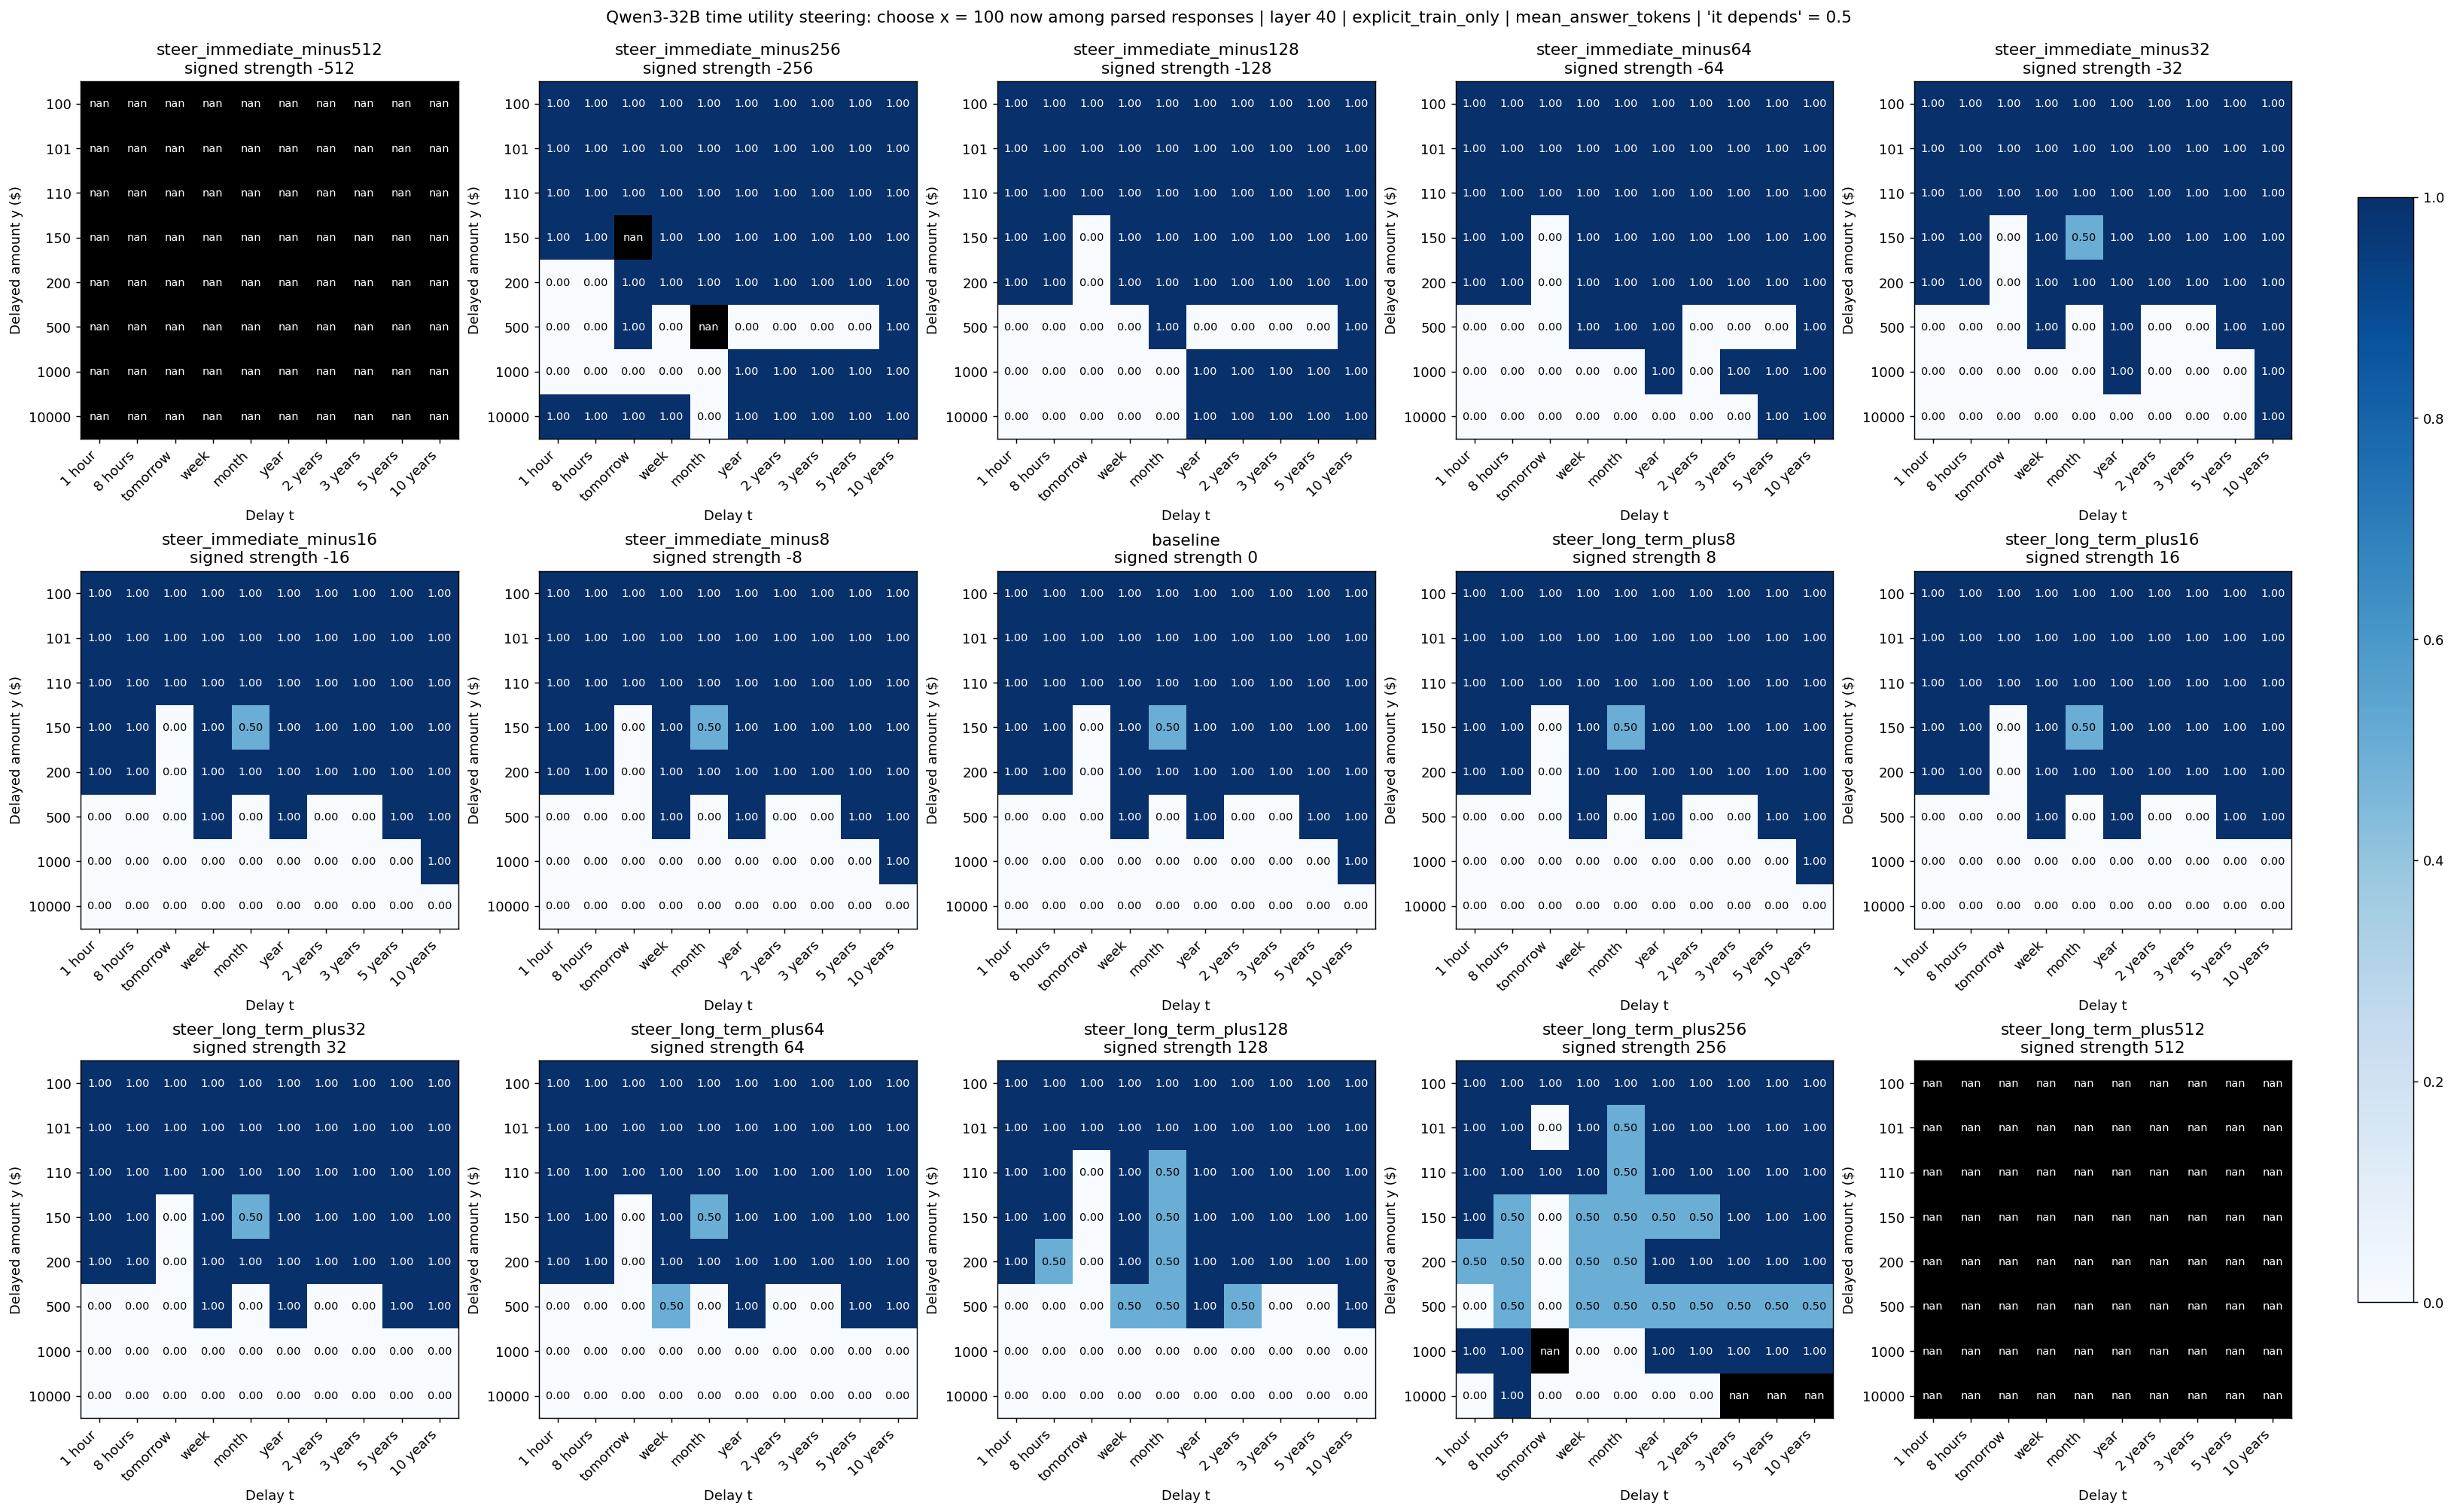

Saved choose-x heatmaps: /Users/michalmraz/code/spar-ai/temporal-awareness/results/qwen3_32b/time_utility_experiment_probe_steered/20260410-111315/replots_from_notebook/qwen3_32b_time_utility_probe_steered_choose_x_now_all_conditions.png
Saved replot index     : /Users/michalmraz/code/spar-ai/temporal-awareness/results/qwen3_32b/time_utility_experiment_probe_steered/20260410-111315/replots_from_notebook/qwen3_32b_time_utility_probe_steered_replots.csv


,plot_type,plot_path,run_dir
0,choose_x_now_all_conditions,/Users/michalmraz/code/spar-ai/temporal-awaren...,/Users/michalmraz/code/spar-ai/temporal-awaren...


In [4]:
if not RUN_AVAILABLE:
    print('Skipping replots because no steered run was found.')
else:
    n_conditions = len(condition_order)
    ncols = min(5, max(1, n_conditions))
    nrows = int(math.ceil(n_conditions / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    image = None
    used_axes = []
    for ax, condition_name in zip(axes, condition_order):
        condition_df = summary_df.loc[summary_df['condition'] == condition_name].copy()
        matrix = to_matrix(
            condition_df,
            'prop_choose_x_parsed',
            y_values=y_values,
            t_values=t_values,
        )
        signed_strength = strength_lookup.get(condition_name)
        title = condition_name if signed_strength is None else f'{condition_name}\nsigned strength {signed_strength:g}'
        image = draw_heatmap(
            ax,
            matrix,
            title,
            y_values=y_values,
            t_values=t_values,
            vmin=0.0,
            vmax=1.0,
            cmap='Blues',
        )
        used_axes.append(ax)

    for ax in axes[len(condition_order):]:
        ax.axis('off')

    suptitle = (
        f"Qwen3-32B time utility steering: choose x = 100 now among parsed responses | "
        f"layer {config.get('steering_layer')} | {config.get('probe_train_regime')} | {config.get('probe_feature_name')} | 'it depends' = 0.5"
    )
    fig.suptitle(suptitle, y=1.02)
    fig.colorbar(image, ax=used_axes, fraction=0.025, pad=0.03)

    combined_plot_path = PLOT_ROOT / 'qwen3_32b_time_utility_probe_steered_choose_x_now_all_conditions.png'
    fig.savefig(combined_plot_path, dpi=200, bbox_inches='tight')
    display(fig)
    plt.close(fig)

    replot_index_df = pd.DataFrame([
        {
            'plot_type': 'choose_x_now_all_conditions',
            'plot_path': str(combined_plot_path),
            'run_dir': str(RUN_DIR),
        }
    ])
    replot_index_path = PLOT_ROOT / 'qwen3_32b_time_utility_probe_steered_replots.csv'
    replot_index_df.to_csv(replot_index_path, index=False)

    print('Saved choose-x heatmaps:', combined_plot_path)
    print('Saved replot index     :', replot_index_path)
    display(replot_index_df)


# Next steps?

- do hte expsrimetn with randomness
- another layer? see from steering results

In [5]:
if not RUN_AVAILABLE:
    print('Skipping raw-results display because no steered run was found.')
else:
    if 'results_df' not in globals() or not isinstance(results_df, pd.DataFrame) or results_df.empty:
        if RAW_PATH is None or not Path(RAW_PATH).exists():
            raise FileNotFoundError(f'Could not find raw CSV for the selected run: {RAW_PATH}')
        results_df = pd.read_csv(RAW_PATH)

    if 'summary_df' not in globals() or not isinstance(summary_df, pd.DataFrame) or summary_df.empty:
        if SUMMARY_PATH is None or not Path(SUMMARY_PATH).exists():
            raise FileNotFoundError(f'Could not find summary CSV for the selected run: {SUMMARY_PATH}')
        summary_df = pd.read_csv(SUMMARY_PATH)

    raw_display_cols = [
        'condition',
        'y_later',
        't_delay',
        'repeat_idx',
        'choice',
        'prompt',
        'response',
        'response_for_parse',
        'signed_strength',
        'steering_applied',
    ]

    nan_cells_df = summary_df.loc[
        summary_df['prop_choose_x_parsed'].isna(),
        ['condition', 'y_later', 't_delay', 'n_total', 'n_parsed', 'n_unparsed', 'unparsed_rate']
    ].copy()

    if len(nan_cells_df):
        print(f'Displaying raw rows for {len(nan_cells_df)} heatmap cells with NaN choose-x values.')
        display(nan_cells_df.sort_values(['condition', 'y_later', 't_delay']).reset_index(drop=True))
        nan_results_df = (
            results_df.merge(
                nan_cells_df[['condition', 'y_later', 't_delay']],
                on=['condition', 'y_later', 't_delay'],
                how='inner',
            )
            .sort_values(['condition', 'y_later', 't_delay', 'repeat_idx'])[raw_display_cols]
            .reset_index(drop=True)
        )
        display(nan_results_df)
    else:
        print('No NaN choose-x heatmap cells found in this run; displaying the full raw results table instead.')
        display(
            results_df.sort_values(['condition', 'y_later', 't_delay', 'repeat_idx'])[raw_display_cols]
            .reset_index(drop=True)
        )


Displaying raw rows for 166 heatmap cells with NaN choose-x values.


,condition,y_later,t_delay,n_total,n_parsed,n_unparsed,unparsed_rate
0,steer_immediate_minus512,100,1 hour,1,0,1,1.0
1,steer_immediate_minus512,100,8 hours,1,0,1,1.0
2,steer_immediate_minus512,100,tomorrow,1,0,1,1.0
3,steer_immediate_minus512,100,week,1,0,1,1.0
4,steer_immediate_minus512,100,month,1,0,1,1.0
...,...,...,...,...,...,...,...
161,steer_long_term_plus512,10000,year,1,0,1,1.0
162,steer_long_term_plus512,10000,2 years,1,0,1,1.0
163,steer_long_term_plus512,10000,3 years,1,0,1,1.0
164,steer_long_term_plus512,10000,5 years,1,0,1,1.0


,condition,y_later,t_delay,repeat_idx,choice,prompt,response,response_for_parse,signed_strength,steering_applied
0,steer_immediate_minus256,150,tomorrow,1,unparsed,What would you prefer 100$ now or 150$ tomorro...,155 is better.,155 is better.,-256.0,True
1,steer_immediate_minus256,500,month,1,unparsed,What would you prefer 100$ now or 500$ in mont...,50 is better.,50 is better.,-256.0,True
2,steer_immediate_minus512,100,1 hour,1,unparsed,What would you prefer 100$ now or 100$ in 1 ho...,is a is a is is is is is is is is is is is is ...,is a is a is is is is is is is is is is is is ...,-512.0,True
3,steer_immediate_minus512,100,10 years,1,unparsed,What would you prefer 100$ now or 100$ in 10 y...,is:: is:: answer is: answer is: answer is: ans...,is:: is:: answer is: answer is: answer is: ans...,-512.0,True
4,steer_immediate_minus512,100,2 years,1,unparsed,What would you prefer 100$ now or 100$ in 2 ye...,is is is answer is answer is answer is answer...,is is is answer is answer is answer is answer...,-512.0,True
...,...,...,...,...,...,...,...,...,...,...
161,steer_long_term_plus512,10000,8 hours,1,unparsed,What would you prefer 100$ now or 10000$ in 8 ...,1.,1.,512.0,True
162,steer_long_term_plus512,10000,month,1,unparsed,What would you prefer 100$ now or 10000$ in mo...,NaN,NaN,512.0,True
163,steer_long_term_plus512,10000,tomorrow,1,unparsed,What would you prefer 100$ now or 10000$ tomor...,1.,1.,512.0,True
164,steer_long_term_plus512,10000,week,1,unparsed,What would you prefer 100$ now or 10000$ in we...,"1. Wealth, wisdom, time, wisdom, wisdom, wisdo...","1. Wealth, wisdom, time, wisdom, wisdom, wisdo...",512.0,True


In [6]:
df = results_df.sort_values(['condition', 'y_later', 't_delay', 'repeat_idx'])[raw_display_cols].reset_index(drop=True)

In [7]:
df.choice.unique()

array(['x_now', 'it depends', 'y_later', 'unparsed'], dtype=object)

In [8]:
df[df.choice == 'unparsed']

,condition,y_later,t_delay,repeat_idx,choice,prompt,response,response_for_parse,signed_strength,steering_applied
277,steer_immediate_minus256,150,tomorrow,1,unparsed,What would you prefer 100$ now or 150$ tomorro...,155 is better.,155 is better.,-256.0,True
296,steer_immediate_minus256,500,month,1,unparsed,What would you prefer 100$ now or 500$ in mont...,50 is better.,50 is better.,-256.0,True
400,steer_immediate_minus512,100,1 hour,1,unparsed,What would you prefer 100$ now or 100$ in 1 ho...,is a is a is is is is is is is is is is is is ...,is a is a is is is is is is is is is is is is ...,-512.0,True
401,steer_immediate_minus512,100,10 years,1,unparsed,What would you prefer 100$ now or 100$ in 10 y...,is:: is:: answer is: answer is: answer is: ans...,is:: is:: answer is: answer is: answer is: ans...,-512.0,True
402,steer_immediate_minus512,100,2 years,1,unparsed,What would you prefer 100$ now or 100$ in 2 ye...,is is is answer is answer is answer is answer...,is is is answer is answer is answer is answer...,-512.0,True
...,...,...,...,...,...,...,...,...,...,...
1035,steer_long_term_plus512,10000,8 hours,1,unparsed,What would you prefer 100$ now or 10000$ in 8 ...,1.,1.,512.0,True
1036,steer_long_term_plus512,10000,month,1,unparsed,What would you prefer 100$ now or 10000$ in mo...,NaN,NaN,512.0,True
1037,steer_long_term_plus512,10000,tomorrow,1,unparsed,What would you prefer 100$ now or 10000$ tomor...,1.,1.,512.0,True
1038,steer_long_term_plus512,10000,week,1,unparsed,What would you prefer 100$ now or 10000$ in we...,"1. Wealth, wisdom, time, wisdom, wisdom, wisdo...","1. Wealth, wisdom, time, wisdom, wisdom, wisdo...",512.0,True


In [9]:
for r in df[df.choice == 'unparsed'].response:
    print('---')
    print(r)

---
155 is better.
---
50 is better.
---
is a is a is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is is task is task is task is task is task is task is task is task is task is task is task is task is task is task is task is task is task is task is task is task is task is task is task is task is task is
---
is:: is:: answer is: answer is: answer is: answer is: answer is: answer is: answer is: is answer is: is is answer is: is is is: is is is: is is is: is is is: is is is: is is is: is is is: is is is: is is is: is is is: is is is: is is is: is is is: is is is: is is is: is is is: is is is: is is is: is is is: is is is: is is is: is is is: is is is:
---
is  is is answer is answer is answer is answer is answer is answer is answer is answer is answer is answer is answer is answer is answer is answer is answer is answer is a

In [10]:
df[(df.choice == 'unparsed') & (df.signed_strength.abs() <= 256)]

,condition,y_later,t_delay,repeat_idx,choice,prompt,response,response_for_parse,signed_strength,steering_applied
277,steer_immediate_minus256,150,tomorrow,1,unparsed,What would you prefer 100$ now or 150$ tomorro...,155 is better.,155 is better.,-256.0,True
296,steer_immediate_minus256,500,month,1,unparsed,What would you prefer 100$ now or 500$ in mont...,50 is better.,50 is better.,-256.0,True
867,steer_long_term_plus256,1000,tomorrow,1,unparsed,What would you prefer 100$ now or 1000$ tomorr...,1000$ over 100.,1000$ over 100.,256.0,True
871,steer_long_term_plus256,10000,10 years,1,unparsed,What would you prefer 100$ now or 10000$ in 10...,1000$ over time.,1000$ over time.,256.0,True
873,steer_long_term_plus256,10000,3 years,1,unparsed,What would you prefer 100$ now or 10000$ in 3 ...,1000$ over time.,1000$ over time.,256.0,True
874,steer_long_term_plus256,10000,5 years,1,unparsed,What would you prefer 100$ now or 10000$ in 5 ...,1000$ over time.,1000$ over time.,256.0,True
